# EN3160 Assignment 1 — Intensity Transformations and Neighborhood Filtering

**Name:** _Perera W.A.L.S._ 

**Index Number:** _230487D_

**GitHub:** https://github.com/Lasan-Perera/EN3160-assignment-1


## Question 1: Piecewise Linear Intensity Transformation

Implement `intensity_transform(im, breakpoints)` and apply it to the given image with the breakpoints from the assignment. Experiment with different breakpoints for a visually pleasing result.

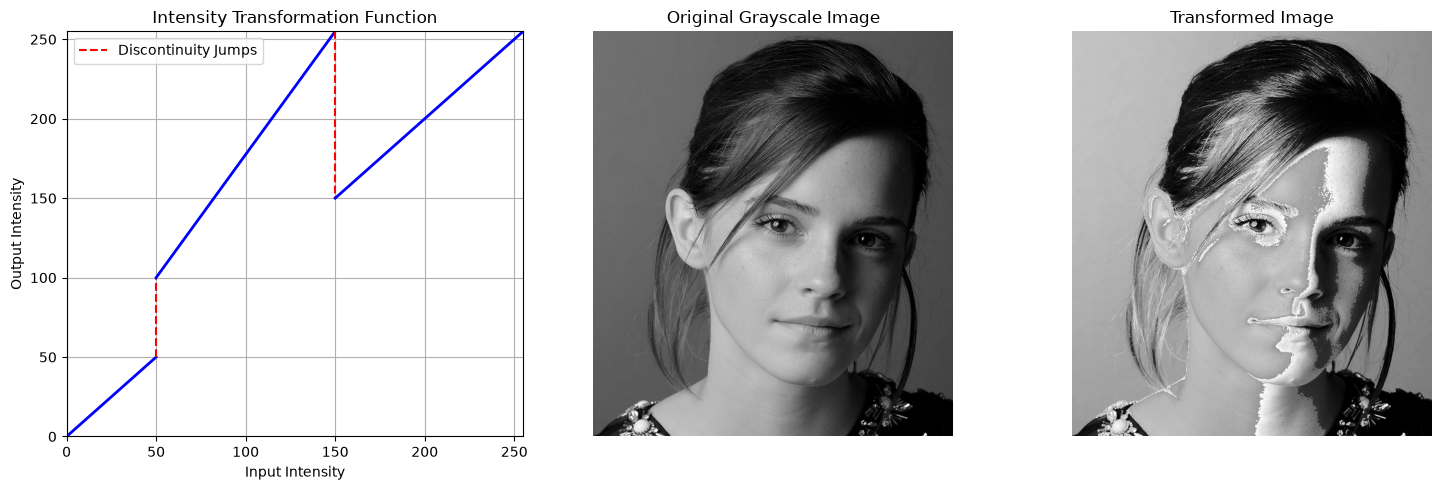

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform_step(im):
    lut = np.zeros(256, dtype=np.uint8)
    
    # 0 <= x < 50 : y = x
    lut[0:50] = np.arange(0, 50)
    
    # 50 <= x < 150 : y maps from 100 to 255
    lut[50:150] = np.linspace(100, 255, 100, endpoint=False).astype(np.uint8)
    
    # 150 <= x <= 255 : y = x
    lut[150:256] = np.arange(150, 256)
    
    transformed_im = cv2.LUT(im, lut)
    return transformed_im, lut

# read the image in grayscale
img_gray = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/emma.jpg', cv2.IMREAD_GRAYSCALE)

# apply the transformation
transformed_img_gray, lut = intensity_transform_step(img_gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# plot piecewise step transformation
axes[0].plot([0, 50], [0, 50], 'b-', linewidth=2)
axes[0].plot([50, 50], [50, 100], 'r--', linewidth=1.5, label='Discontinuity Jumps')
axes[0].plot([50, 150], [100, 255], 'b-', linewidth=2)
axes[0].plot([150, 150], [255, 150], 'r--', linewidth=1.5)
axes[0].plot([150, 255], [150, 255], 'b-', linewidth=2)

axes[0].set_title('Intensity Transformation Function')
axes[0].set_xlabel('Input Intensity')
axes[0].set_ylabel('Output Intensity')
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)
axes[0].legend()

# original Image
axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original Grayscale Image')
axes[1].axis('off')

# transformed Image
axes[2].imshow(transformed_img_gray, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Question 2: Accentuating White and Gray Matter

Apply piecewise linear intensity transformations to the brain proton density image to accentuate (a) white matter and (b) gray matter separately.

### Brain Tissue Intensity Thresholds

For this implementation, we use the following 8-bit intensity thresholds:

- **0–70:** CSF
- **70–140:** Gray Matter (GM)
- **140–255:** White Matter (WM)

These thresholds are used as practical segmentation limits. MRI intensity values can vary between scanners and acquisition protocols, so these values are specific to our image-processing implementation rather than universal MRI thresholds.

**Source:** [Robitaille et al., 2012 — Tissue-Based MRI Intensity Standardization](https://pmc.ncbi.nlm.nih.gov/articles/PMC3352580/)

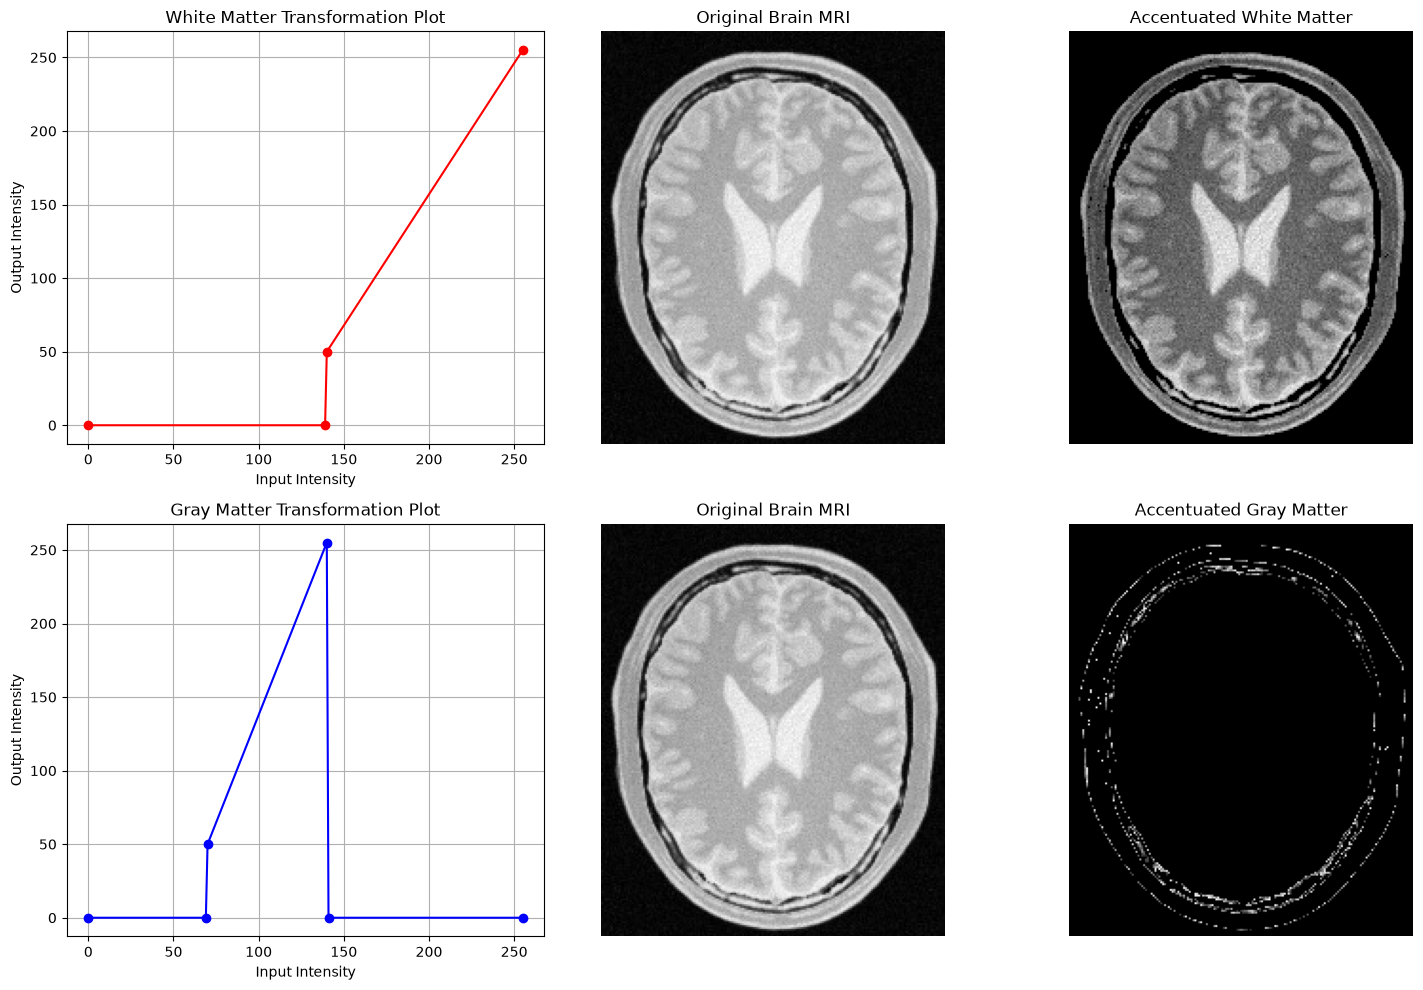

In [22]:
def apply_custom_lut(img, breakpoints):
    """
    Constructs a piecewise linear LUT from breakpoints [(x0,y0), (x1,y1), ...]
    and applies it to the grayscale image.
    """
    breakpoints = np.array(breakpoints)
    x_pts = breakpoints[:, 0]
    y_pts = breakpoints[:, 1]
    
    input_range = np.arange(256)
    lut = np.interp(input_range, x_pts, y_pts).astype(np.uint8)
    
    transformed = cv2.LUT(img, lut)
    return transformed, lut

# Read the brain MRI image in grayscale
brain_img = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/brainProton.jpeg', cv2.IMREAD_GRAYSCALE)

# Define breakpoints for White Matter (WM: 140–255)
breakpoints_wm = [
    [0, 0],
    [139, 0],
    [140, 50],
    [255, 255]
]

# Define breakpoints for Gray Matter (GM: 70–140)
breakpoints_gm = [
    [0, 0],
    [69, 0],
    [70, 50],
    [140, 255],
    [141, 0],
    [255, 0]
]

# Apply transformations
img_wm, lut_wm = apply_custom_lut(brain_img, breakpoints_wm)
img_gm, lut_gm = apply_custom_lut(brain_img, breakpoints_gm)

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# White Matter Transformation Plot
axes[0, 0].plot([p[0] for p in breakpoints_wm], [p[1] for p in breakpoints_wm], 'r-o')
axes[0, 0].set_title('White Matter Transformation Plot')
axes[0, 0].set_xlabel('Input Intensity')
axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].grid(True)

axes[0, 1].imshow(brain_img, cmap='gray')
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_wm, cmap='gray')
axes[0, 2].set_title('Accentuated White Matter')
axes[0, 2].axis('off')

# Gray Matter Transformation Plot
axes[1, 0].plot([p[0] for p in breakpoints_gm], [p[1] for p in breakpoints_gm], 'b-o')
axes[1, 0].set_title('Gray Matter Transformation Plot')
axes[1, 0].set_xlabel('Input Intensity')
axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].grid(True)

axes[1, 1].imshow(brain_img, cmap='gray')
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_gm, cmap='gray')
axes[1, 2].set_title('Accentuated Gray Matter')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Question 3: Gamma Correction on the L Plane (L*a*b*)

Convert to L*a*b*, apply gamma correction to the L plane, state the gamma value used, and compare histograms before and after correction.

Applied Gamma Value is 0.2


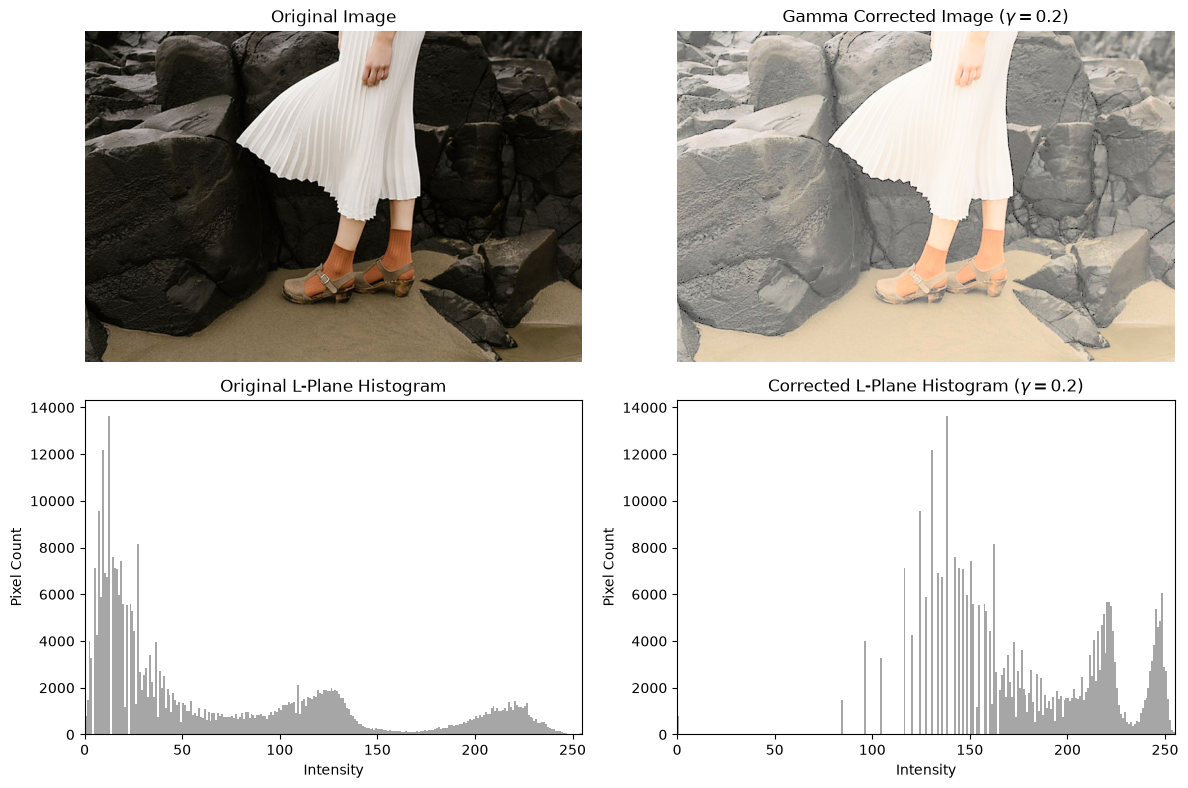

In [27]:
img_bgr = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/q3GammaCorr.jpeg') 
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to L*a*b* color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# Apply Gamma Correction to L plane
# gamma value < 1.0 brightens dark areas
# gamma value > 1.0 darkens bright areas
gamma = 0.2  
L_normalized = L / 255.0
L_corrected = np.uint8(np.clip((L_normalized ** gamma) * 255, 0, 255))

# Merge corrected L channel with original a and b channels, then convert back to RGB
img_lab_corrected = cv2.merge([L_corrected, a, b])
img_bgr_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)
img_rgb_corrected = cv2.cvtColor(img_bgr_corrected, cv2.COLOR_BGR2RGB)

print(f"Applied Gamma Value is {gamma}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original Image
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Gamma Corrected Image
axes[0, 1].imshow(img_rgb_corrected)
axes[0, 1].set_title(rf"Gamma Corrected Image ($\gamma = {gamma}$)")
axes[0, 1].axis("off")

# Original L-channel Histogram
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 0].set_title("Original L-Plane Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])

# Gamma Corrected L-channel Histogram
axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 1].set_title(rf"Corrected L-Plane Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()


## Question 4: Vibrance Enhancement via Saturation Plane

Split into HSV planes, apply the given Gaussian-weighted saturation boost f(x) with chosen a and sigma=70, recombine, and display results.

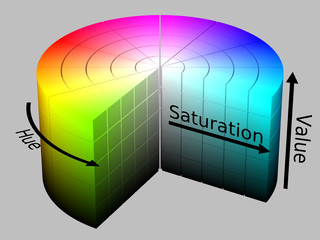

Reported chosen parameter value: a = 0.5


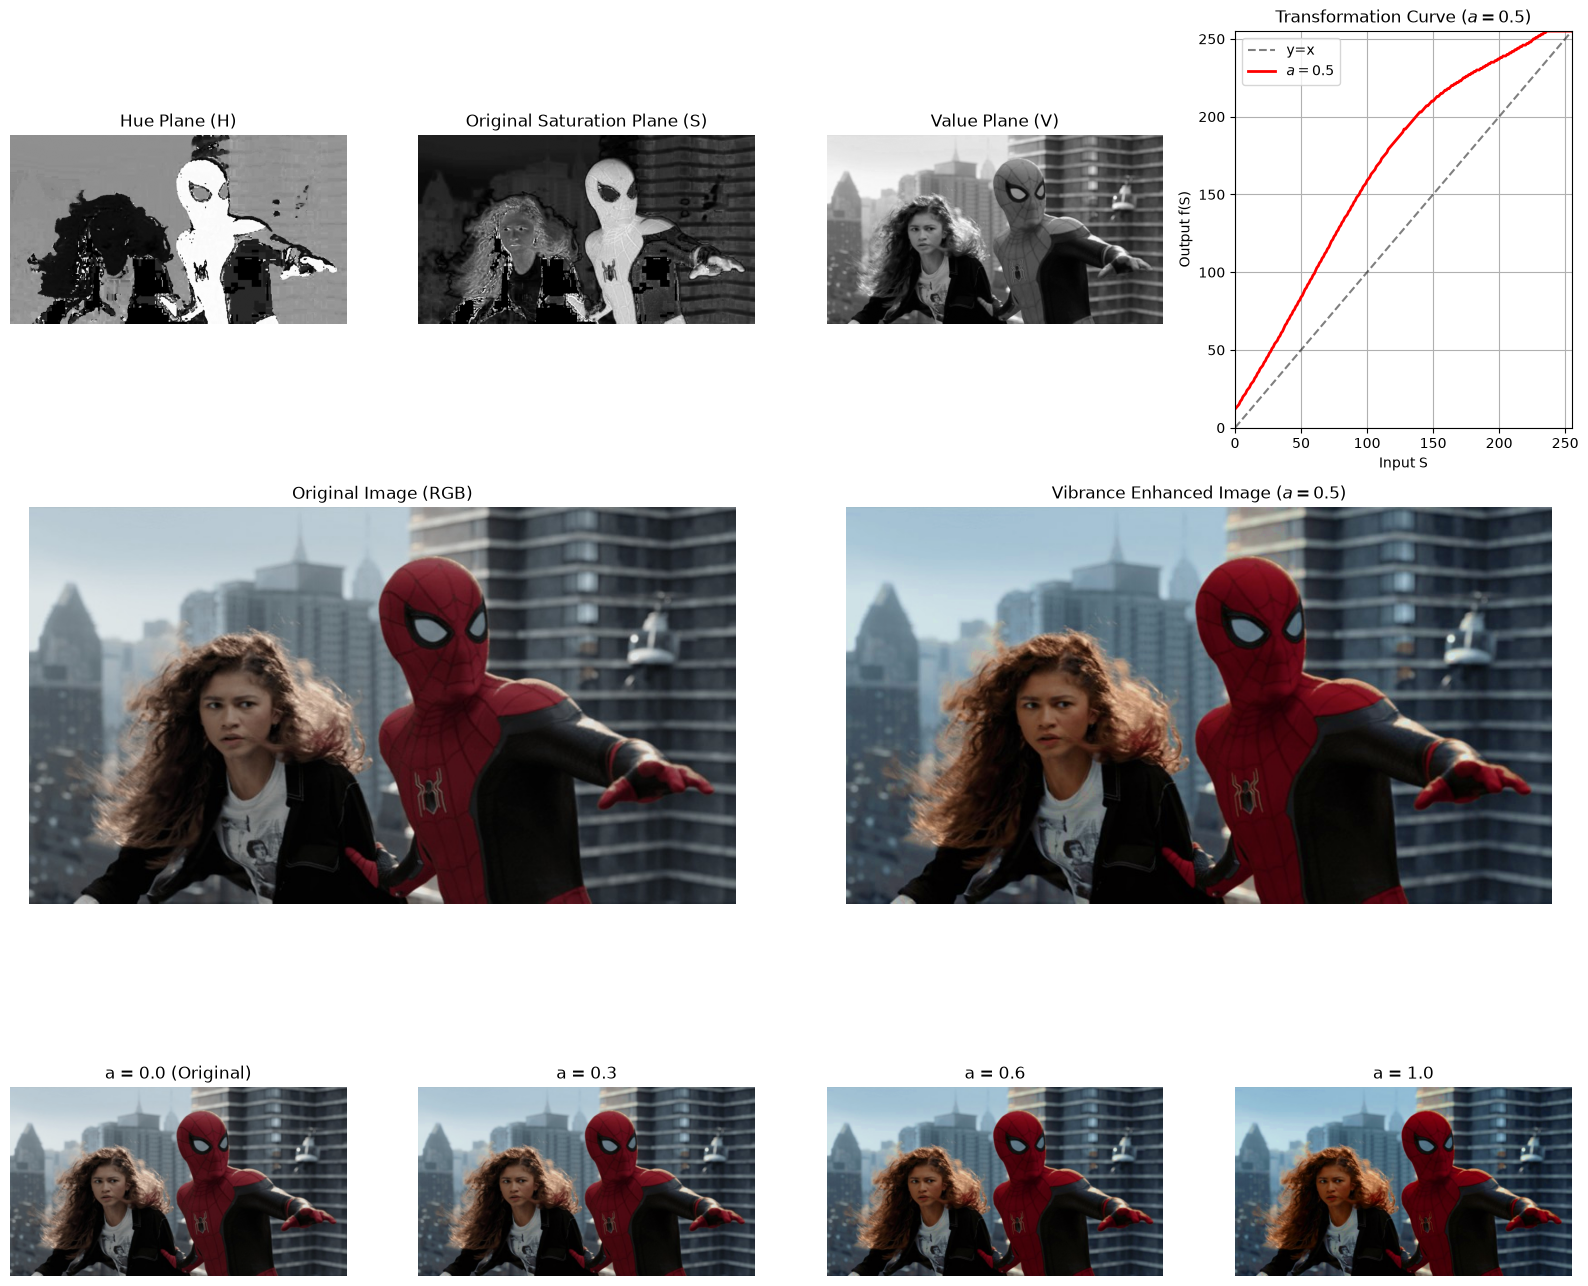

In [32]:
def vibrance_transform(s_channel, a, sigma=70):
    x = np.arange(256, dtype=np.float32)
    boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma ** 2)))
    fx = np.clip(x + boost, 0, 255).astype(np.uint8)
    s_enhanced = cv2.LUT(s_channel, fx)
    return s_enhanced, x, fx

img_bgr = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/SpiderMan.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to HSV color space and split channels
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

# parameter for vibrance enhancement
a_param = 0.5
print(f"Reported chosen parameter value: a = {a_param}")
s_enhanced, x_vals, fx_vals = vibrance_transform(s, a=a_param, sigma=70)

img_hsv_enhanced = cv2.merge([h, s_enhanced, v])
img_rgb_enhanced = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2RGB)

# Visualisation
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 4)

# HSV Planes and Transformation Curve
ax_h = fig.add_subplot(gs[0, 0])
ax_h.imshow(h, cmap='gray')
ax_h.set_title("Hue Plane (H)")
ax_h.axis("off")

ax_s = fig.add_subplot(gs[0, 1])
ax_s.imshow(s, cmap='gray')
ax_s.set_title("Original Saturation Plane (S)")
ax_s.axis("off")

ax_v = fig.add_subplot(gs[0, 2])
ax_v.imshow(v, cmap='gray')
ax_v.set_title("Value Plane (V)")
ax_v.axis("off")

# Curve plot spanning 1 column
ax_curve = fig.add_subplot(gs[0, 3])
ax_curve.plot(x_vals, x_vals, 'k--', alpha=0.5, label='y=x')
ax_curve.plot(x_vals, fx_vals, 'r-', linewidth=2, label=rf'$a={a_param}$')
ax_curve.set_title(rf"Transformation Curve ($a={a_param}$)")
ax_curve.set_xlabel("Input S")
ax_curve.set_ylabel("Output f(S)")
ax_curve.set_xlim([0, 255])
ax_curve.set_ylim([0, 255])
ax_curve.grid(True)
ax_curve.legend()

# before & after side-by-side
ax_orig = fig.add_subplot(gs[1, 0:2])
ax_orig.imshow(img_rgb)
ax_orig.set_title("Original Image (RGB)")
ax_orig.axis("off")

ax_enh = fig.add_subplot(gs[1, 2:4])
ax_enh.imshow(img_rgb_enhanced)
ax_enh.set_title(rf"Vibrance Enhanced Image ($a={a_param}$)")
ax_enh.axis("off")

# Effect of Varying Parameter 'a'
a_values = [0.0, 0.3, 0.6, 1.0]

for idx, a_val in enumerate(a_values):
    ax_a = fig.add_subplot(gs[2, idx])
    s_test, _, _ = vibrance_transform(s, a=a_val, sigma=70)
    hsv_test = cv2.merge([h, s_test, v])
    rgb_test = cv2.cvtColor(hsv_test, cv2.COLOR_HSV2RGB)
    
    ax_a.imshow(rgb_test)
    if a_val == 0.0:
        ax_a.set_title(f"a = {a_val} (Original)")
    else:
        ax_a.set_title(f"a = {a_val}")
    ax_a.axis("off")

plt.tight_layout()
plt.show()

## Question 5: Histogram Equalization (Custom Implementation)

Write your own histogram equalization function (no cv.equalizeHist) and show histograms before/after.

**Discussion:**

_(interpretation of results goes here)_

## Question 6: Foreground-Only Histogram Equalization

Split into HSV, threshold an appropriate plane to build a foreground mask, histogram-equalize only the foreground using cumulative sums, then recombine with the untouched background.

**Discussion:**

_(interpretation of results goes here)_

## Question 7: Sobel Filtering

(a) Use cv.filter2D with Sobel kernels. (b) Implement Sobel filtering manually. (c) Exploit the separable kernel property to filter with 1D convolutions.

**Discussion:**

_(interpretation of results goes here)_

## Question 8: Image Zooming (Nearest-Neighbor and Bilinear)

Write a zoom function supporting nearest-neighbor and bilinear interpolation for scale factor s in (0, 10]. Evaluate using normalized SSD against the original when scaling up by 4x.

**Discussion:**

_(interpretation of results goes here)_

## Question 9: GrabCut Segmentation and Background Blur

(a) Segment the flower image with cv.grabCut, showing mask, foreground, and background. (b) Blur the background to produce a bokeh-style enhanced image. (c) Discuss the dark rim artifact.

**Discussion:**

_(interpretation of results goes here)_

## Question 10: Bilateral Filtering

(a) Use cv.bilateralFilter and compare against a similarly-sized Gaussian blur. (b) Implement your own bilateral filter, compare against OpenCV's version with a quantitative measure.

**Discussion:**

_(interpretation of results goes here)_